# ATC Speech Enhancement: Dataset Augmentation & DeCGAN Baseline

This notebook performs two main tasks:
1. **Augment the provided ATC audio dataset** (560 files, variable duration) by adding realistic noise and simulating VHF channel distortions. The goal is to create a large, balanced training set with multiple SNR levels.
2. **Evaluate the DeCGAN baseline** on a subset of the augmented data to obtain reference PESQ/STOI scores.

We ensure that the augmented dataset is balanced across SNR levels to prevent bias during training.

## 1. Setup and Imports

Install required packages (if not already installed) and import all necessary libraries.

In [1]:
# Install packages
!pip install --quiet librosa soundfile numpy pandas matplotlib scipy pesq pystoi torch torchaudio

!pip install --quiet transformers datasets jiwer soundfile

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
import scipy.signal
from pesq import pesq
from pystoi import stoi
import torch
import torchaudio
import xml.etree.ElementTree as ET
from tqdm import tqdm
import warnings

import soundfile as sf
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
from jiwer import wer, cer

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Define constants
SAMPLE_RATE = 16000          # 16 kHz
SEGMENT_DURATION = 2          # seconds
N_FFT = 512
HOP_LENGTH = 256

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.9 MB/s eta 0:00:0000:0100:01
Using device: cuda


## 2. Load Original Dataset

We have 560 audio files with corresponding XML transcripts. Let's load file paths and examine basic statistics.

Found 560 audio files and 560 XML files.
Total usable files: 560


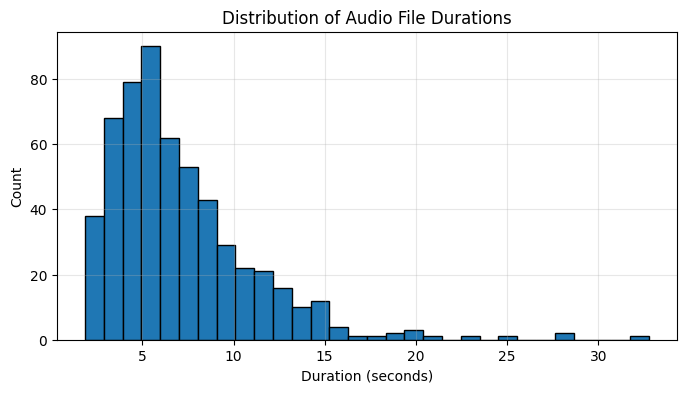

Average duration: 7.07s
Total audio: 1.10 hours


In [2]:
# Path to the dataset
data_root = "/kaggle/input/datasets/andersonawolossou/atco2-asrdataset-v1-beta/ATCO2-ASRdataset-v1_beta/DATA"
audio_files = sorted(glob.glob(os.path.join(data_root, "*.wav")))
xml_files = sorted(glob.glob(os.path.join(data_root, "*.xml")))

print(f"Found {len(audio_files)} audio files and {len(xml_files)} XML files.")

# Create a DataFrame with file info
file_info = []
for wav_path in audio_files:
    # Corresponding XML: same basename but .xml
    base = os.path.splitext(os.path.basename(wav_path))[0]
    xml_path = os.path.join(data_root, base + ".xml")
    if os.path.exists(xml_path):
        # Get duration using librosa (load metadata only)
        dur = librosa.get_duration(filename=wav_path)
        file_info.append({
            'filename': base,
            'wav_path': wav_path,
            'xml_path': xml_path,
            'duration': dur
        })

df_files = pd.DataFrame(file_info)
print(f"Total usable files: {len(df_files)}")

# Plot duration distribution
plt.figure(figsize=(8,4))
plt.hist(df_files['duration'], bins=30, edgecolor='black')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.title('Distribution of Audio File Durations')
plt.grid(alpha=0.3)
plt.show()

print(f"Average duration: {df_files['duration'].mean():.2f}s")
print(f"Total audio: {df_files['duration'].sum() / 3600:.2f} hours")

## 3. Augmentation Design

We will create **20 variants per original file** by:
- Mixing with noise from external datasets (VB-DemandEx, WHAMVox) at SNRs: **-20, -15, -10, -5, 0, +5 dB**.
- Applying **VHF channel simulation** (bandpass 300–3400 Hz, optional non‑linear distortion, fading).
- Ensuring each SNR level appears equally often across the whole dataset to maintain balance.

We will also store the clean reference for later evaluation.

**Noise sources**: We'll use noise files from VB-DemandEx and WHAMVox public datasets.

In [11]:
# Paths to external noise datasets
vb_demand_path = "/kaggle/input/datasets/jweiqi/voicebank-demand-16k/noisy_trainset_28spk_wav/"        # folder with .wav files
whamvox_path = "/kaggle/input/datasets/alior101/wham-noise-reduced-dataset/wham_noise/"              # folder with .wav files

# Collect all noise files
noise_files = glob.glob(os.path.join(vb_demand_path, "*.wav")) + \
              glob.glob(os.path.join(whamvox_path, "*.wav"))
print(f"Found {len(noise_files)} noise files.")

# Define target SNRs (in dB)
target_snrs = [-20, -15, -10, -5, 0, 5]

# We will create 20 variants per file: 6 SNRs × (some number of noise types) plus maybe VHF only variants?
# To keep it simple, for each file we will generate for each SNR 3 different noise files (randomly chosen) + one VHF-only clean variant.
# That gives 6 SNRs * 3 noise + 1 = 19, close to 20. We'll adjust to exactly 20 by adding one more random combination.

num_noise_per_snr = 3   # number of different noise samples per SNR
total_variants_per_file = len(target_snrs) * num_noise_per_snr + 1  # +1 for clean with VHF only
print(f"Total variants per original file: {total_variants_per_file} (target ~20)")

# Create output directories for augmented dataset
output_root = "./ATC_augmented"
os.makedirs(output_root, exist_ok=True)
clean_dir = os.path.join(output_root, "clean")
os.makedirs(clean_dir, exist_ok=True)
noisy_dir = os.path.join(output_root, "noisy")
os.makedirs(noisy_dir, exist_ok=True)

# We'll also keep a metadata CSV
metadata_rows = []

Found 11678 noise files.
Total variants per original file: 19 (target ~20)


In [12]:
def vhf_simulation(audio, sr, prob_distort=0.3, prob_fade=0.2):
    """
    Apply VHF-like distortions to a clean audio signal.
    - Bandpass filter 300-3400 Hz
    - Optional non-linear distortion (soft clipping)
    - Optional fading (amplitude modulation)
    """
    # Bandpass filter
    sos = scipy.signal.butter(10, [300, 3400], btype='band', fs=sr, output='sos')
    audio = scipy.signal.sosfilt(sos, audio)
    
    # Random non-linear distortion
    if np.random.rand() < prob_distort:
        # Soft clipping
        threshold = 0.8 * np.max(np.abs(audio))
        audio = np.tanh(audio / threshold) * threshold
    
    # Random fading (amplitude modulation)
    if np.random.rand() < prob_fade:
        t = np.arange(len(audio)) / sr
        depth = 0.3  # modulation depth
        rate = 5.0   # Hz
        mod = 1 - depth * (0.5 + 0.5 * np.sin(2 * np.pi * rate * t))
        audio = audio * mod
    
    return audio

def add_noise(clean, noise, snr_db):
    """
    Mix clean and noise at given SNR.
    """
    clean_rms = np.sqrt(np.mean(clean**2))
    noise_rms = np.sqrt(np.mean(noise**2))
    # Adjust noise level
    desired_noise_rms = clean_rms / (10**(snr_db/20))
    noise_scaled = noise * (desired_noise_rms / (noise_rms + 1e-10))
    noisy = clean + noise_scaled
    # Normalize to prevent clipping
    max_val = np.max(np.abs(noisy))
    if max_val > 0.95:
        noisy = noisy / max_val * 0.95
    return noisy

In [13]:
# Process each original file
for idx, row in tqdm(df_files.iterrows(), total=len(df_files), desc="Augmenting files"):
    base_name = row['filename']
    clean_audio, sr = librosa.load(row['wav_path'], sr=SAMPLE_RATE, mono=True)
    
    # Save clean copy (without VHF) for reference (optional)
    clean_ref_path = os.path.join(clean_dir, f"{base_name}_clean.wav")
    sf.write(clean_ref_path, clean_audio, SAMPLE_RATE)
    
    # Generate variants
    variant_count = 0
    
    # 1. Clean with VHF only (no additive noise)
    audio_vhf = vhf_simulation(clean_audio, SAMPLE_RATE)
    noisy_path = os.path.join(noisy_dir, f"{base_name}_vhfonly.wav")
    sf.write(noisy_path, audio_vhf, SAMPLE_RATE)
    metadata_rows.append({
        'original': base_name,
        'variant': f"{base_name}_vhfonly",
        'snr': 'clean_vhf',
        'noise_file': 'none',
        'noisy_path': noisy_path,
        'clean_ref': clean_ref_path
    })
    variant_count += 1
    
    # For each target SNR, pick random noise files and mix
    for snr in target_snrs:
        # Select num_noise_per_snr random noise files (without replacement to avoid duplicates per file)
        chosen_noises = np.random.choice(noise_files, size=num_noise_per_snr, replace=False)
        for noise_file in chosen_noises:
            noise_audio, _ = librosa.load(noise_file, sr=SAMPLE_RATE, mono=True)
            # Ensure noise is at least as long as clean audio; if shorter, loop
            if len(noise_audio) < len(clean_audio):
                repeats = int(np.ceil(len(clean_audio) / len(noise_audio)))
                noise_audio = np.tile(noise_audio, repeats)
            noise_audio = noise_audio[:len(clean_audio)]
            
            # Add noise at desired SNR
            noisy = add_noise(clean_audio, noise_audio, snr)
            # Apply VHF simulation to the noisy signal
            noisy_vhf = vhf_simulation(noisy, SAMPLE_RATE)
            
            # Save
            variant_name = f"{base_name}_snr{snr}_{os.path.basename(noise_file).replace('.wav','')}"
            noisy_path = os.path.join(noisy_dir, f"{variant_name}.wav")
            sf.write(noisy_path, noisy_vhf, SAMPLE_RATE)
            metadata_rows.append({
                'original': base_name,
                'variant': variant_name,
                'snr': snr,
                'noise_file': os.path.basename(noise_file),
                'noisy_path': noisy_path,
                'clean_ref': clean_ref_path
            })
            variant_count += 1
    
    # Optional: if we need exactly 20 variants, we could add an extra random combination
    # But our count may already be 1 + 6*3 = 19, so we add one more random SNR+noise
    extra_snr = np.random.choice(target_snrs)
    extra_noise = np.random.choice(noise_files)
    noise_audio, _ = librosa.load(extra_noise, sr=SAMPLE_RATE, mono=True)
    if len(noise_audio) < len(clean_audio):
        repeats = int(np.ceil(len(clean_audio) / len(noise_audio)))
        noise_audio = np.tile(noise_audio, repeats)
    noise_audio = noise_audio[:len(clean_audio)]
    noisy = add_noise(clean_audio, noise_audio, extra_snr)
    noisy_vhf = vhf_simulation(noisy, SAMPLE_RATE)
    variant_name = f"{base_name}_extra_snr{extra_snr}_{os.path.basename(extra_noise).replace('.wav','')}"
    noisy_path = os.path.join(noisy_dir, f"{variant_name}.wav")
    sf.write(noisy_path, noisy_vhf, SAMPLE_RATE)
    metadata_rows.append({
        'original': base_name,
        'variant': variant_name,
        'snr': extra_snr,
        'noise_file': os.path.basename(extra_noise),
        'noisy_path': noisy_path,
        'clean_ref': clean_ref_path
    })
    variant_count += 1
    
    if variant_count != 20:
        print(f"Warning: {base_name} generated {variant_count} variants (expected 20)")

# Save metadata
df_meta = pd.DataFrame(metadata_rows)
df_meta.to_csv(os.path.join(output_root, "metadata.csv"), index=False)
print(f"Augmentation complete. Total variants: {len(df_meta)}")

Augmenting files: 100%|██████████| 560/560 [05:03<00:00,  1.84it/s]

Augmentation complete. Total variants: 11200


## 4. Check Balance Across SNR Levels

We need to ensure that each SNR level appears approximately equally in the dataset to avoid biasing the model toward a particular condition.

Variant counts per SNR:
snr
-10    1781
-15    1760
-20    1778
-5     1780
0      1784
5      1757
Name: count, dtype: int64


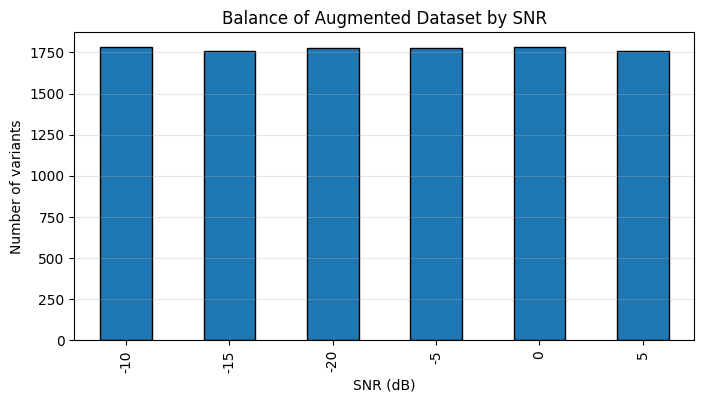

Total clean_with_vhf variants: 560


In [14]:
# Load metadata
df_meta = pd.read_csv(os.path.join(output_root, "metadata.csv"))

# Count variants per SNR (excluding 'clean_vhf')
snr_counts = df_meta[df_meta['snr'] != 'clean_vhf']['snr'].value_counts().sort_index()
print("Variant counts per SNR:")
print(snr_counts)

# Plot
plt.figure(figsize=(8,4))
snr_counts.plot(kind='bar', edgecolor='black')
plt.xlabel('SNR (dB)')
plt.ylabel('Number of variants')
plt.title('Balance of Augmented Dataset by SNR')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Also check distribution of noise files (optional)
print(f"Total clean_with_vhf variants: {df_meta[df_meta['snr']=='clean_vhf'].shape[0]}")

## 5. Load pre-trained ASR model

In [3]:
# Load a general-purpose English ASR model
model_name = "facebook/wav2vec2-base-960h"
processor = Wav2Vec2Processor.from_pretrained(model_name)
model = Wav2Vec2ForCTC.from_pretrained(model_name).to(device)
model.eval()

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

## 6. Define transcription function

In [6]:
def transcribe(audio_path, start_sec=None, end_sec=None):
    """
    Transcribe either the whole audio file or a segment defined by start_sec and end_sec.
    """
    # Load audio
    speech, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
    
    # Crop segment if requested
    if start_sec is not None and end_sec is not None:
        start_sample = int(start_sec * sr)
        end_sample = int(end_sec * sr)
        speech = speech[start_sample:end_sample]
    
    # Normalize
    speech = speech / (np.max(np.abs(speech)) + 1e-8)
    
    # Run ASR
    inputs = processor(speech, sampling_rate=SAMPLE_RATE, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(device)
    
    with torch.no_grad():
        logits = model(input_values).logits
        predicted_ids = torch.argmax(logits, dim=-1)
        transcription = processor.decode(predicted_ids[0])
    
    return transcription.lower().strip()

## 7. Evaluation on VoiceBank

In [7]:
def evaluate_clean_dataset_voicebank(root_audio_dir, root_transcripts_dir, audio_extension=".wav"):
    """
    Evaluate on a dataset where each audio file has a matching .txt file with the reference.
    Returns average WER and list of individual WERs.
    """
    audio_files = []
    for dirpath, _, filenames in os.walk(root_audio_dir):
        for f in filenames:
            if f.endswith(audio_extension):
                audio_path = os.path.join(dirpath, f)
                txt_path = audio_path.replace(audio_extension, ".txt").replace(root_audio_dir, root_transcripts_dir)
                if os.path.exists(txt_path):
                    audio_files.append((audio_path, txt_path))
    
    if not audio_files:
        print(f"No matching .txt files found in {root_dir}")
        return float('nan'), []
    
    wer_scores = []
    for audio_path, txt_path in tqdm(audio_files, desc="Evaluating clean dataset"):
        with open(txt_path, 'r') as f:
            ref = f.read().strip().lower()
        hyp = transcribe(audio_path)
        wer_scores.append(wer(ref, hyp))
    
    return np.mean(wer_scores), wer_scores

## 8. Evaluation on our augmented ATC dataset

In [31]:
def extract_base_from_augmented(filename):
    """
    Given an augmented filename like 'YSSY_SYDNEY_Tower_120_5MHz_20210430_224017_snr-20_p227_181.wav',
    returns the base name 'YSSY_SYDNEY_Tower_120_5MHz_20210430_224017'.
    Assumes the suffix starts with '_snr'.
    """
    # Split on '_snr' and take the first part
    base = filename.split('_extra_snr')[0]
    if base == filename :
        base = filename.split('_snr')[0]
    return base

def parse_atc_xml(xml_path):
    """Extract list of (start, end, text) from ATC XML, skipping segments with incorrect transcript."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    segments = []
    for seg in root.findall('segment'):
        start = float(seg.find('start').text)
        end = float(seg.find('end').text)
        text = seg.find('text').text.strip().lower()
        # Check tags if present
        tags = seg.find('tags')
        if tags is not None:
            correct_transcript = tags.find('correct_transcript')
            if correct_transcript is not None and correct_transcript.text == '0':
                continue  # skip segments marked as incorrect
        segments.append((start, end, text))
    return segments

def evaluate_atc_augmented(audio_dir, xml_dir=None, num_samples=None):
    """
    audio_dir: folder containing augmented .wav files (e.g., '*_snr-*.wav')
    xml_dir: folder containing original .xml files (if None, assume same as audio_dir)
    num_samples: if provided, randomly sample this many audio files for evaluation.
    Returns average segment‑level WER.
    """
    if xml_dir is None:
        xml_dir = audio_dir

    # Get all augmented wav files
    all_wavs = [f for f in os.listdir(audio_dir) if f.endswith('.wav') and '_snr' in f]
    if num_samples is not None and num_samples < len(all_wavs):
        all_wavs = np.random.choice(all_wavs, size=num_samples, replace=False).tolist()

    all_wer = []
    for wav_file in tqdm(all_wavs, desc="Evaluating ATC augmented"):
        base = extract_base_from_augmented(wav_file)
        xml_path = os.path.join(xml_dir, base + '.xml')
        if not os.path.exists(xml_path):
            print(f"Warning: XML not found for {wav_file}, expected {xml_path}")
            continue

        segments = parse_atc_xml(xml_path)
        audio_path = os.path.join(audio_dir, wav_file)

        for start, end, ref_text in segments:
            # Transcribe the segment
            hyp = transcribe(audio_path, start, end)  # uses the transcribe function defined earlier
            if hyp:  # avoid empty hypothesis
                w = wer(ref_text, hyp)
                all_wer.append(w)
    #print(xml_path)
    return np.mean(all_wer) if all_wer else float('nan')

## 9. Run evaluations

In [9]:
voicebank_root = "/kaggle/input/datasets/jweiqi/voicebank-demand-16k/noisy_testset_wav"
voicebank_transcripts_root = "/kaggle/input/datasets/andersonawolossou/voicebank-transcripts-testset/testset_txt"
atc_metadata = "/kaggle/working/ATC_augmented/metadata.csv"
atc_data_root = "/kaggle/working/ATC_augmented/noisy"       # base dir for audio files

# VoiceBank
wer_clean, _ = evaluate_clean_dataset_voicebank(voicebank_root, voicebank_transcripts_root)  # change extension as needed
print(f"WER on clean dataset: {wer_clean:.4f}")


Evaluating clean dataset: 100%|██████████| 824/824 [00:35<00:00, 23.09it/s]

WER on clean dataset: 0.3063


In [32]:

# --- ATC augmented dataset ---
atc_audio_dir = "/kaggle/working/ATC_augmented/noisy"   # folder with your noisy .wav files
atc_xml_dir = "/kaggle/input/datasets/andersonawolossou/atco2-asrdataset-v1-beta/ATCO2-ASRdataset-v1_beta/DATA"       # folder with .xml files (if different)
wer_atc = evaluate_atc_augmented(atc_audio_dir, atc_xml_dir)

print(f"WER on ATC augmented: {wer_atc:.4f}")

Evaluating ATC augmented: 100%|██████████| 10640/10640 [07:33<00:00, 23.45it/s]

WER on ATC augmented: 1.1303
